# Taller — Construye y ajusta tu propio clasificador de imágenes

Este taller comienza **después de la teoría de CNN y del notebook guiado de transfer learning**.

La meta no es memorizar la API de Keras. La meta es tomar decisiones sobre un problema real: construir datos propios, adaptar un modelo preentrenado y analizar qué tan bien funciona.

---

## Organización de la actividad

| Momento | Tiempo estimado | Meta |
|---|---:|---|
| **Teoría + notebook guiado** | Se realiza antes de este taller | Comprender CNN, transfer learning y fine-tuning |
| **Trabajo en clase** | ~60 min | Construir el dataset y entrenar el primer modelo con la base congelada |
| **Trabajo en casa** | ~1–2 h | Evaluar, hacer fine-tuning, comparar y analizar errores |

### Regla importante

Durante el trabajo en clase usaremos **train** y **validation**.  
El conjunto de **test** se reservará para el trabajo en casa, cuando hagamos la evaluación final.

---

## Entrega final

Debes entregar **este mismo notebook ejecutado**, incluyendo:

- definición del problema y estrategia de búsqueda;
- dataset propio;
- primer entrenamiento con transfer learning;
- evaluación en test;
- fine-tuning;
- comparación antes/después;
- matriz de confusión;
- análisis de al menos 5 errores;
- conclusiones.

## 0. Preparación del entorno

La búsqueda de imágenes se realizará con `ddgs`. Si estás en Google Colab, ejecuta la siguiente celda.

In [1]:
!pip -q install -U ddgs

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from pathlib import Path
import hashlib, io, random, shutil, time
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image

import tensorflow as tf
import keras
from keras import layers
from ddgs import DDGS
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Keras: 3.13.2
TensorFlow: 2.21.0
GPU: []


# PARTE A — TRABAJO EN CLASE (~60 min)

## Objetivo de esta parte

Antes de terminar la sesión debes haber conseguido:

1. definir un problema de clasificación de 3 clases;
2. descargar y revisar un dataset propio;
3. separar los datos en `train`, `validation` y `test`;
4. cargar EfficientNetB0 preentrenada en ImageNet;
5. congelar el backbone;
6. entrenar una nueva cabeza de clasificación;
7. observar `accuracy` y `val_accuracy`.

> **No evalúes todavía sobre `test`.** Ese conjunto queda reservado para el trabajo en casa.

### Distribución sugerida

- **10 min** — problema y términos de búsqueda;
- **20 min** — descarga, inspección y limpieza;
- **10 min** — separación y carga del dataset;
- **20 min** — transfer learning y primer entrenamiento.

# 1. Define tu problema — EN CLASE

Elige un problema de clasificación de **3 clases**. Las clases deben ser visualmente distinguibles.

Ejemplos: `espresso/cappuccino/latte`, `bus/motorcycle/bicycle`, tres especies de flores, frutas, tipos de calzado o instrumentos musicales.

Evita problemas donde la clase dependa de información que no aparece visualmente en la imagen.

## TODO 1 — Problema y estrategia de búsqueda

Define:

1. Las tres clases: guitarra, violín y trompeta.

2. Términos de búsqueda: están en el código. Usé términos en inglés y en español porque los buscadores suelen dar más y mejores imágenes en inglés. Varias búsquedas por clase ayudan a que las fotos sean más variadas.

3. Hipótesis: espero que el modelo se fije en la forma general y en los materiales.

Guitarra: cuerpo grande con forma de “ocho”, mástil largo y cuerdas.

Violín: cuerpo más pequeño y curvo, color madera brillante y, muchas veces, un arco.

Trompeta: color dorado o metálico brillante, tubos enrollados y la boquilla.

Creo que el color y el brillo (madera frente a metal) serán la pista más fuerte, y la forma del cuerpo ayudará a separar la guitarra del violín.

4. Posible sesgo o data leakage: Imágenes duplicadas o casi iguales - si dos búsquedas devuelven la misma foto (o versiones recortadas o con otro tamaño) y una cae en train y la otra en test, el modelo “ya la vio” y el resultado se ve mejor de lo que es.
Sesgo del fondo y del contexto - las fotos de buscador suelen ser de tienda con fondo blanco, y las trompetas pueden salir en fotos de orquesta. El modelo podría aprender el fondo en lugar del instrumento.

In [3]:
# TODO 1 — EN CLASE: define tus clases y búsquedas
SEARCHES = {
    "guitarra": [
        "acoustic guitar",
        "guitar instrument photo",
        "guitarra acustica",
        "classical guitar on stand",
    ],
    "violin": [
        "violin instrument",
        "violin photo",
        "violin musical instrument close up",
        "violin with bow on table",
        "violin isolated",
    ],
    "trompeta": [
        "trumpet instrument",
        "trumpet brass instrument photo",
        "trompeta instrumento",
        "bb trumpet close up",
        "trumpet isolated",
    ],
}

SEARCHES

{'guitarra': ['acoustic guitar',
  'guitar instrument photo',
  'guitarra acustica',
  'classical guitar on stand'],
 'violin': ['violin instrument',
  'violin photo',
  'violin musical instrument close up',
  'violin with bow on table',
  'violin isolated'],
 'trompeta': ['trumpet instrument',
  'trumpet brass instrument photo',
  'trompeta instrumento',
  'bb trumpet close up',
  'trumpet isolated']}

### Antes de descargar

Escribe debajo de esta celda una respuesta corta:

**¿Qué características visuales esperas que diferencien tus clases?**
Espero que el modelo use el **color y el material** (madera para guitarra y violín, metal dorado brillante para la trompeta) y la **forma del cuerpo**: la guitarra es grande con mástil largo, el violín es más pequeño y curvo, y la trompeta tiene tubos enrollados con una campana al final.

**¿Qué imágenes incorrectas esperas encontrar?**
Espero fotos de **otros instrumentos parecidos** (guitarras eléctricas y bajos, violonchelos y violas, trombones y cornetas), **dibujos, logos e ilustraciones**, **personas tocando** donde casi no se ve el instrumento, y **fotos de tiendas u orquestas** con varios instrumentos juntos.

**¿Qué sesgo o data leakage podría aparecer?**
Pueden aparecer **fotos duplicadas o casi iguales** (la misma imagen con otro tamaño o recorte) que queden repartidas entre train y test, haciendo que el resultado parezca mejor de lo real. También hay **sesgo de fondo**: muchas fotos de tienda tienen fondo blanco y las de trompeta suelen venir de bandas, así que el modelo podría aprender el fondo en vez del instrumento.


# 2. Buscar y descargar imágenes — EN CLASE

La siguiente función busca imágenes y descarga los resultados. Intenta ignorar URLs fallidas, verificar las imágenes, evitar duplicados exactos con un hash y convertirlas a RGB.

> Se solicita contenido con licencia Creative Commons cuando el motor lo soporta. Eso no sustituye la revisión de licencias si el dataset se va a redistribuir.

In [4]:
RAW_DIR = Path("data_raw")
RAW_DIR.mkdir(exist_ok=True)

def file_sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def download_image_dataset(searches, root=RAW_DIR, images_per_query=60, min_side=120, timeout=8):
    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0"})

    # Incluye imágenes de ejecuciones anteriores para que volver a ejecutar
    # la descarga no agregue duplicados exactos al dataset.
    seen_hashes = {
        file_sha256(path)
        for path in Path(root).glob("*/*.jpg")
        if path.is_file()
    }

    for class_name, queries in searches.items():
        class_dir = root / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        saved = len(list(class_dir.glob("*.jpg")))
        print(f"\n=== {class_name} ===")

        for query in queries:
            print(f"Buscando: {query!r}")
            try:
                results = DDGS().images(
                    query=query,
                    safesearch="moderate",
                    max_results=images_per_query,
                    license_image="any",
                )
            except Exception as e:
                print("  Error en búsqueda:", e)
                continue

            for result in results:
                url = result.get("image")
                if not url:
                    continue
                try:
                    response = session.get(url, timeout=timeout)
                    response.raise_for_status()
                    data = response.content
                    digest = hashlib.sha256(data).hexdigest()
                    if digest in seen_hashes:
                        continue

                    with Image.open(io.BytesIO(data)) as img:
                        img = img.convert("RGB")
                        if min(img.size) < min_side:
                            continue
                        filename = class_dir / f"{saved:04d}.jpg"
                        img.save(filename, format="JPEG", quality=90)

                    seen_hashes.add(digest)
                    saved += 1
                except Exception:
                    pass

            print(f"  Total guardadas hasta ahora: {saved}")
            time.sleep(1)

    print("\nDescarga terminada.")

## TODO 2 — EN CLASE: construye y limpia tu dataset

Tu objetivo inicial es obtener aproximadamente **100–150 imágenes útiles por clase**.

1. Ejecuta la descarga.
2. Inspecciona muestras aleatorias.
3. Mejora los términos de búsqueda si una clase trae resultados pobres.
4. Elimina imágenes claramente incorrectas o problemáticas.
5. Reporta el número final de imágenes por clase y describe el error más frecuente que encontraste.

> Si la búsqueda trae datos malos, **no aumentes simplemente `max_results`**. Primero mejora los términos de búsqueda.

In [5]:
# TODO 2 — EN CLASE: ejecuta la descarga con tus búsquedas
download_image_dataset(
    SEARCHES,
    images_per_query=60,
)


=== guitarra ===
Buscando: 'acoustic guitar'
  Total guardadas hasta ahora: 40
Buscando: 'guitar instrument photo'
  Total guardadas hasta ahora: 72
Buscando: 'guitarra acustica'
  Total guardadas hasta ahora: 94
Buscando: 'classical guitar on stand'
  Total guardadas hasta ahora: 128

=== violin ===
Buscando: 'violin instrument'
  Total guardadas hasta ahora: 33
Buscando: 'violin photo'
  Total guardadas hasta ahora: 59
Buscando: 'violin musical instrument close up'
  Total guardadas hasta ahora: 93
Buscando: 'violin with bow on table'
  Total guardadas hasta ahora: 127
Buscando: 'violin isolated'
  Total guardadas hasta ahora: 153

=== trompeta ===
Buscando: 'trumpet instrument'
  Total guardadas hasta ahora: 31
Buscando: 'trumpet brass instrument photo'
  Total guardadas hasta ahora: 59
Buscando: 'trompeta instrumento'
  Total guardadas hasta ahora: 89
Buscando: 'bb trumpet close up'
  Total guardadas hasta ahora: 111
Buscando: 'trumpet isolated'
  Total guardadas hasta ahora: 141


In [6]:
def count_images(root):
    counts = {}
    for folder in sorted(Path(root).iterdir()):
        if folder.is_dir():
            counts[folder.name] = len(list(folder.glob("*.jpg")))
    return counts

count_images(RAW_DIR)

{'guitarra': 128, 'trompeta': 141, 'violin': 153}

## Validación técnica automática de las imágenes

Antes de inspeccionar el contenido del dataset, comprobaremos que **TensorFlow pueda decodificar todas las imágenes**.

Esto resuelve un problema distinto al de la inspección visual:

- **Validación técnica:** ¿el archivo puede ser leído correctamente por TensorFlow?
- **Validación semántica:** ¿la imagen realmente pertenece a la clase indicada?

Una imagen puede abrirse aparentemente bien en otras librerías y aun así fallar durante `model.fit()`. Por eso hacemos esta comprobación usando el mismo decoder que utilizará el pipeline de Keras.

In [7]:
def remove_invalid_images(root_dir):
    root_dir = Path(root_dir)
    bad_files = []

    for path in root_dir.rglob("*.jpg"):
        try:
            raw = tf.io.read_file(str(path))

            img = tf.io.decode_image(
                raw,
                channels=3,
                expand_animations=False,
            )

            # Forzamos la ejecución para detectar errores de decodificación.
            _ = img.numpy()

        except Exception as e:
            print("Imagen inválida:", path)
            print(" ", str(e).splitlines()[0])
            bad_files.append(path)

    for path in bad_files:
        path.unlink(missing_ok=True)

    print(f"\nImágenes inválidas eliminadas: {len(bad_files)}")

    return bad_files


bad_files = remove_invalid_images(RAW_DIR)


Imágenes inválidas eliminadas: 0


### Verificación

Ejecuta nuevamente la función. El resultado esperado es:

```text
Imágenes inválidas eliminadas: 0
```

Si todavía aparece alguna imagen inválida, vuelve a ejecutar hasta obtener cero antes de continuar.

In [8]:
bad_files = remove_invalid_images(RAW_DIR)

assert len(bad_files) == 0, (
    "Todavía quedan imágenes que TensorFlow no puede decodificar."
)

print("✓ Todas las imágenes pueden ser decodificadas por TensorFlow.")


Imágenes inválidas eliminadas: 0
✓ Todas las imágenes pueden ser decodificadas por TensorFlow.


# 3. Inspección y limpieza semántica — EN CLASE

La etapa anterior confirmó que los archivos son **técnicamente válidos**.

Ahora viene una tarea diferente: comprobar si los datos son **semánticamente correctos**.

Busca especialmente:

- imágenes que no correspondan a la clase;
- dibujos, logos o diagramas si tu objetivo son fotografías;
- imágenes con texto que pueda revelar artificialmente la etiqueta;
- duplicados o imágenes casi idénticas;
- fondos que estén correlacionados con una clase;
- diferencias sistemáticas de estilo o calidad entre clases.

> Que TensorFlow pueda abrir una imagen no significa que sea un buen dato de entrenamiento.

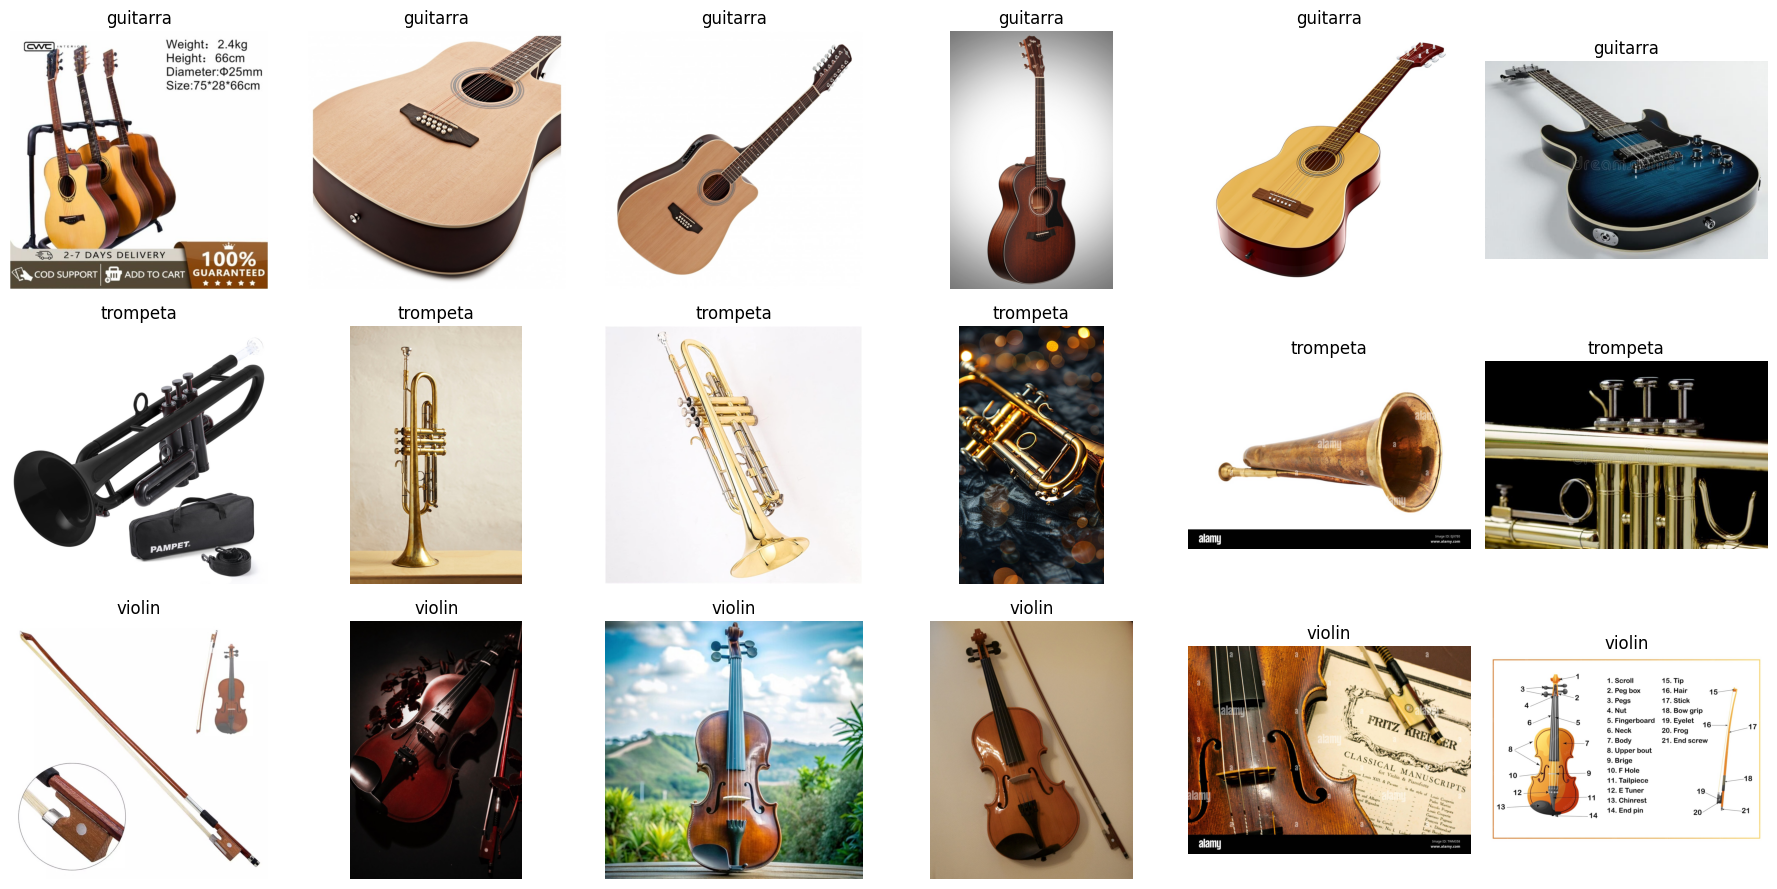

In [9]:
def show_random_images(root, n_per_class=6):
    root = Path(root)
    class_dirs = [p for p in sorted(root.iterdir()) if p.is_dir()]
    fig, axes = plt.subplots(len(class_dirs), n_per_class, figsize=(3*n_per_class, 3*len(class_dirs)))
    if len(class_dirs) == 1:
        axes = np.expand_dims(axes, 0)
    for row, class_dir in enumerate(class_dirs):
        files = list(class_dir.glob("*.jpg"))
        chosen = random.sample(files, min(n_per_class, len(files)))
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(chosen):
                img = Image.open(chosen[col])
                ax.imshow(img)
                ax.set_title(class_dir.name)
            ax.axis("off")
    plt.tight_layout()

show_random_images(RAW_DIR)

### Checkpoint del dataset

Antes de continuar, asegúrate de que:

- cada carpeta contiene imágenes realmente asociadas a su clase;
- no predominan logos, dibujos o texto que revele la etiqueta;
- no hay una diferencia de fondo/estilo demasiado obvia entre clases;
- el número de imágenes por clase es razonablemente balanceado.

Registra aquí el número de imágenes eliminadas y el problema de calidad más frecuente.

In [11]:
import numpy as np

def dhash(path, size=8):
    img = Image.open(path).convert("L").resize((size + 1, size))
    a = np.asarray(img, dtype=np.int16)
    return (a[:, 1:] > a[:, :-1]).flatten()

all_files = sorted(RAW_DIR.glob("*/*.jpg"))
hashes = [dhash(p) for p in all_files]

near_dups = []
for i in range(len(all_files)):
    for j in range(i + 1, len(all_files)):
        if np.count_nonzero(hashes[i] != hashes[j]) <= 4:
            near_dups.append((all_files[i], all_files[j]))

print("Pares casi idénticos:", len(near_dups))
for a, b in near_dups[:30]:
    print(a.parent.name, a.name, "<->", b.parent.name, b.name)

Pares casi idénticos: 46
guitarra 0000.jpg <-> guitarra 0010.jpg
guitarra 0001.jpg <-> guitarra 0013.jpg
guitarra 0002.jpg <-> guitarra 0015.jpg
guitarra 0003.jpg <-> guitarra 0017.jpg
guitarra 0004.jpg <-> guitarra 0019.jpg
guitarra 0005.jpg <-> guitarra 0022.jpg
guitarra 0006.jpg <-> guitarra 0025.jpg
guitarra 0007.jpg <-> guitarra 0027.jpg
guitarra 0008.jpg <-> guitarra 0029.jpg
guitarra 0009.jpg <-> guitarra 0030.jpg
guitarra 0018.jpg <-> guitarra 0023.jpg
guitarra 0018.jpg <-> guitarra 0034.jpg
guitarra 0020.jpg <-> guitarra 0024.jpg
guitarra 0020.jpg <-> guitarra 0034.jpg
guitarra 0020.jpg <-> guitarra 0072.jpg
guitarra 0020.jpg <-> guitarra 0077.jpg
guitarra 0023.jpg <-> guitarra 0024.jpg
guitarra 0023.jpg <-> guitarra 0034.jpg
guitarra 0024.jpg <-> guitarra 0034.jpg
guitarra 0024.jpg <-> guitarra 0072.jpg
guitarra 0024.jpg <-> guitarra 0077.jpg
guitarra 0033.jpg <-> guitarra 0036.jpg
guitarra 0033.jpg <-> guitarra 0037.jpg
guitarra 0033.jpg <-> guitarra 0038.jpg
guitarra 0033.j

In [12]:
REJECT_DIR = Path("data_rejected")

BAD_FILES = {
    "guitarra": [],   # ejemplo: ["0007.jpg", "0033.jpg"]
    "violin": [],
    "trompeta": [],
}

removed = 0
for class_name, names in BAD_FILES.items():
    (REJECT_DIR / class_name).mkdir(parents=True, exist_ok=True)
    for name in names:
        src = RAW_DIR / class_name / name
        if src.exists():
            src.rename(REJECT_DIR / class_name / name)
            removed += 1

print("Imágenes eliminadas en limpieza semántica:", removed)

Imágenes eliminadas en limpieza semántica: 0


In [13]:
counts = {c.name: len(list(c.glob("*.jpg"))) for c in sorted(RAW_DIR.iterdir()) if c.is_dir()}
print(counts)
print("Razón mayor/menor:", round(max(counts.values()) / min(counts.values()), 2))

{'guitarra': 128, 'trompeta': 141, 'violin': 153}
Razón mayor/menor: 1.2


In [14]:
for c in sorted(RAW_DIR.iterdir()):
    if c.is_dir():
        vals = [np.asarray(Image.open(p).convert("L").resize((64, 64))).mean() for p in c.glob("*.jpg")]
        print(f"{c.name}: brillo promedio {np.mean(vals):.0f} (0 = negro, 255 = blanco)")

guitarra: brillo promedio 163 (0 = negro, 255 = blanco)
trompeta: brillo promedio 172 (0 = negro, 255 = blanco)
violin: brillo promedio 124 (0 = negro, 255 = blanco)


Misma clase: 36 | Clases distintas: 10


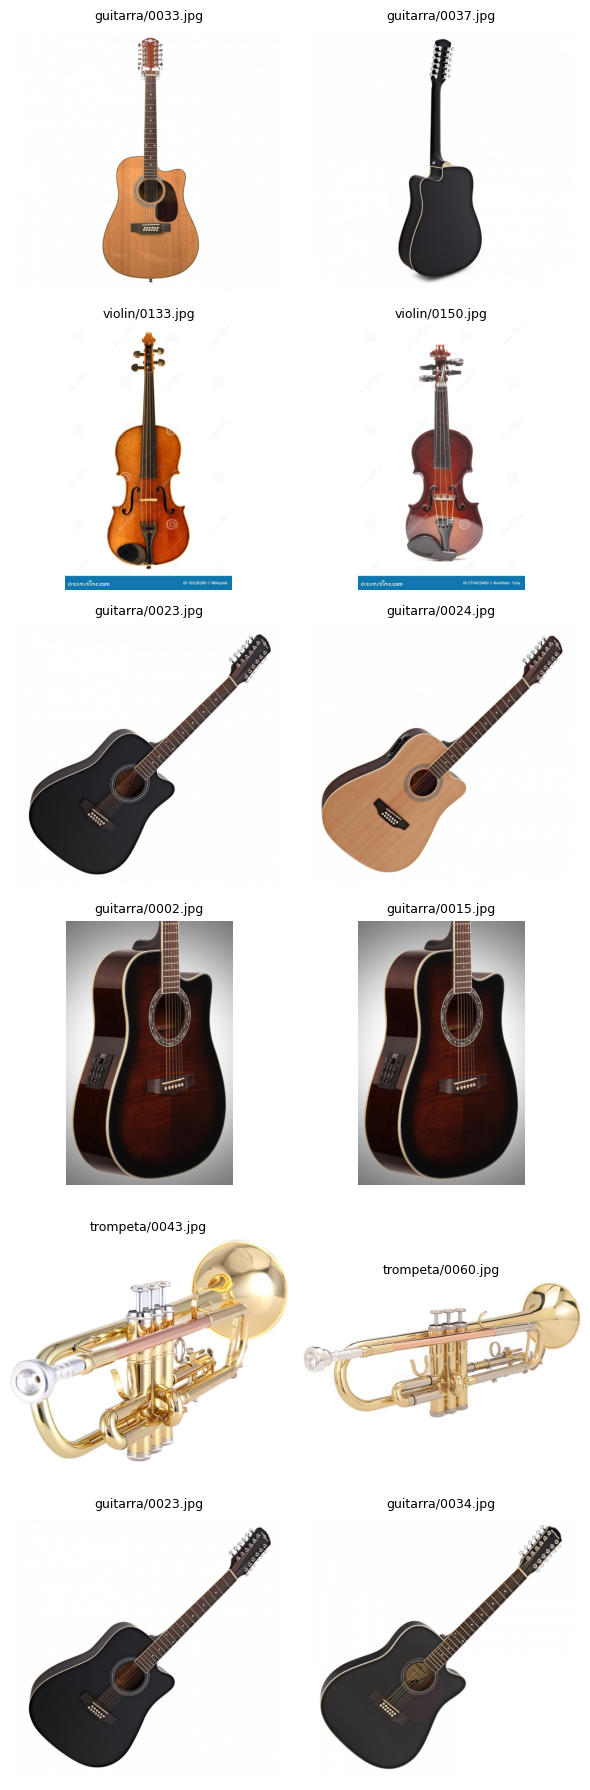

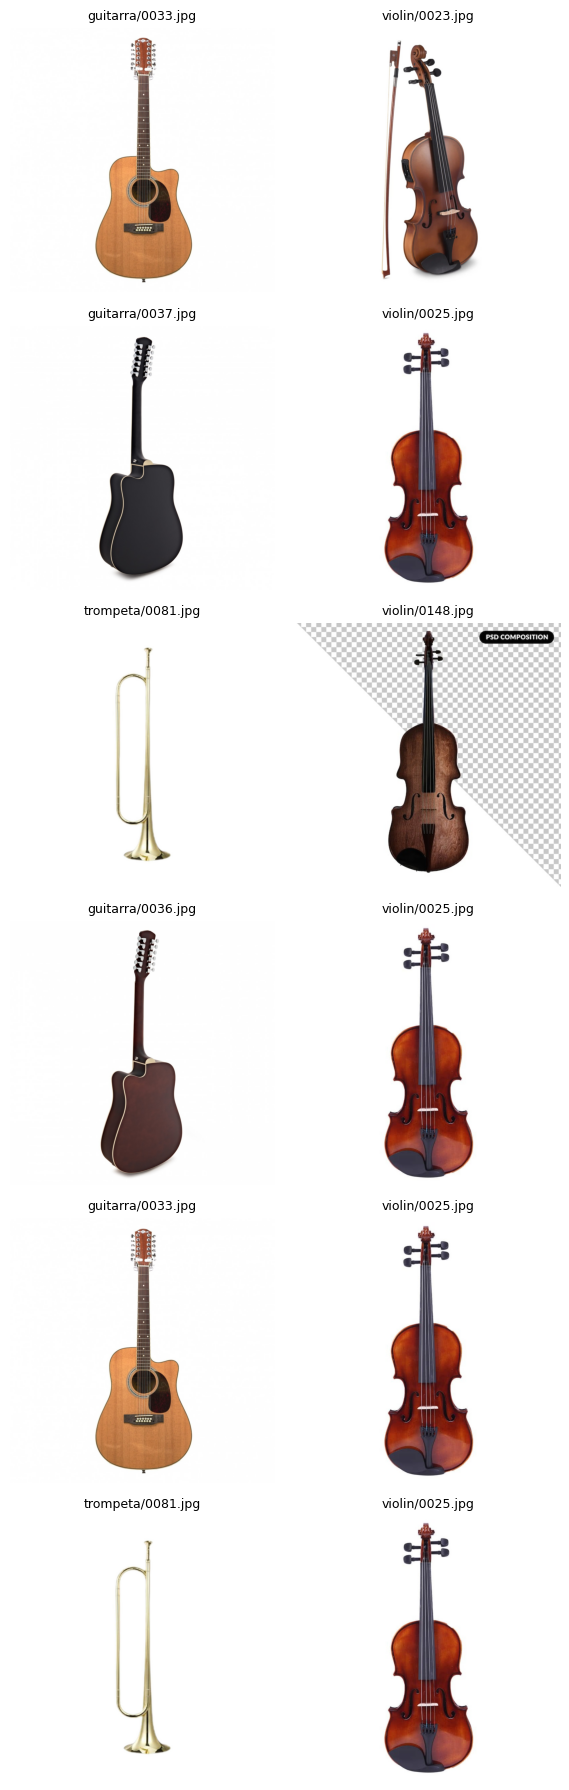

In [15]:
same, cross = [], []
for a, b in near_dups:
    (same if a.parent.name == b.parent.name else cross).append((a, b))
print("Misma clase:", len(same), "| Clases distintas:", len(cross))

def show_pairs(pairs, n=6):
    chosen = random.sample(pairs, min(n, len(pairs)))
    fig, axes = plt.subplots(len(chosen), 2, figsize=(6, 3 * len(chosen)))
    axes = np.atleast_2d(axes)
    for r, (a, b) in enumerate(chosen):
        for c, p in enumerate((a, b)):
            axes[r, c].imshow(Image.open(p))
            axes[r, c].set_title(f"{p.parent.name}/{p.name}", fontsize=9)
            axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

show_pairs(same)
if cross:
    show_pairs(cross)

In [16]:
THRESH = 2   # más bajo = más estricto. Si en el paso 1 viste fotos distintas, deja 2 o usa 1.

dup_remove = set()
for i in range(len(all_files)):
    if all_files[i] in dup_remove:
        continue
    for j in range(i + 1, len(all_files)):
        if all_files[j] in dup_remove:
            continue
        if np.count_nonzero(hashes[i] != hashes[j]) <= THRESH:
            dup_remove.add(all_files[j])
            if all_files[i].parent != all_files[j].parent:   # clases distintas: quitar ambas
                dup_remove.add(all_files[i])

dup_dir = Path("data_rejected") / "duplicados"
dup_dir.mkdir(parents=True, exist_ok=True)
for p in dup_remove:
    p.rename(dup_dir / f"{p.parent.name}_{p.name}")

print("Duplicados eliminados:", len(dup_remove))

Duplicados eliminados: 18


In [17]:
counts = {c.name: len(list(c.glob("*.jpg"))) for c in sorted(RAW_DIR.iterdir()) if c.is_dir()}
print(counts, "| razón mayor/menor:", round(max(counts.values()) / min(counts.values()), 2))

{'guitarra': 113, 'trompeta': 140, 'violin': 151} | razón mayor/menor: 1.34


# 4. Separar train, validation y test — EN CLASE

> **Concepto clave — tres conjuntos, tres funciones**
>
> - **Train:** se utiliza para actualizar los pesos del modelo.
> - **Validation:** se utiliza durante el desarrollo para decidir épocas, `learning_rate`, número de capas a descongelar, etc.
> - **Test:** se reserva para medir el rendimiento final. No debe guiar las decisiones de entrenamiento.

Usaremos **70 % entrenamiento, 15 % validación y 15 % prueba**.

In [18]:
SPLIT_DIR = Path("dataset")

def split_dataset(source_root, destination_root, train_ratio=0.70, val_ratio=0.15, seed=SEED):
    source_root = Path(source_root)
    destination_root = Path(destination_root)
    if destination_root.exists():
        shutil.rmtree(destination_root)
    rng = random.Random(seed)

    for class_dir in sorted(source_root.iterdir()):
        if not class_dir.is_dir():
            continue
        files = list(class_dir.glob("*.jpg"))
        rng.shuffle(files)
        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        splits = {
            "train": files[:n_train],
            "validation": files[n_train:n_train+n_val],
            "test": files[n_train+n_val:],
        }
        for split_name, split_files in splits.items():
            target = destination_root / split_name / class_dir.name
            target.mkdir(parents=True, exist_ok=True)
            for src in split_files:
                shutil.copy2(src, target / src.name)

split_dataset(RAW_DIR, SPLIT_DIR)
for split in ["train", "validation", "test"]:
    print(split, count_images(SPLIT_DIR / split))

train {'guitarra': 79, 'trompeta': 98, 'violin': 105}
validation {'guitarra': 16, 'trompeta': 21, 'violin': 22}
test {'guitarra': 18, 'trompeta': 21, 'violin': 24}


### Comprobación conceptual

Explica brevemente: ¿por qué usar repetidamente el conjunto de prueba para escoger épocas, `learning_rate` o capas a descongelar termina contaminando nuestra estimación de desempeño? Si usas el test para escoger épocas, learning_rate o capas a descongelar, terminas ajustando el modelo a esas mismas fotos, así que el test deja de ser un examen sorpresa y la nota final se ve mejor de lo que el modelo rendiría con imágenes nuevas.

# 5. Construir los datasets de Keras — EN CLASE

`image_dataset_from_directory()` construye un `tf.data.Dataset` usando el nombre de las carpetas como clases.

Observa que:

- `train` se mezcla (`shuffle=True`);
- `validation` y `test` mantienen un orden estable;
- todas las imágenes se redimensionan a `224×224` para EfficientNetB0.

In [19]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED)
val_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)
test_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
print(class_names)

Found 282 files belonging to 3 classes.
Found 59 files belonging to 3 classes.
Found 63 files belonging to 3 classes.
['guitarra', 'trompeta', 'violin']


# 6. Primer modelo: transfer learning — EN CLASE

Usaremos **EfficientNetB0** preentrenada en ImageNet. Primero congelaremos completamente la red base y entrenaremos solo una nueva cabeza de clasificación.

> **Concepto clave — Data augmentation**
>
> `RandomFlip`, `RandomRotation` y `RandomZoom` generan variaciones plausibles durante el entrenamiento. No crean información nueva, pero ayudan a que el modelo dependa menos de detalles accidentales de las imágenes descargadas.

> **Concepto clave — GlobalAveragePooling2D**
>
> En lugar de aplanar todos los mapas de características con `Flatten`, `GlobalAveragePooling2D` resume cada canal en un solo valor. Así reducimos mucho el número de parámetros de la cabeza de clasificación.

In [20]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name="augmentation")

base_model = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## TODO 3 — EN CLASE: entrena la cabeza de clasificación

La base EfficientNet está congelada. Tu trabajo es configurar y entrenar la nueva cabeza.

> **Concepto clave — EarlyStopping**
>
> `EarlyStopping` detiene el entrenamiento cuando `val_loss` deja de mejorar. Con `restore_best_weights=True`, Keras recupera los pesos de la mejor época observada en validación.

Antes de ejecutar, escribe una predicción corta:

¿Esperas que train_accuracy suba rápidamente? Sí, porque la red base ya sabe “ver” y solo se entrena una capa pequeña; creo que desde las primeras 2 o 3 épocas pasará del 80 %. Puede subir un poco más lento de lo esperado por la augmentation y el dropout, que hacen el entrenamiento más difícil a propósito.

¿Qué señal indicaría overfitting? Que train_accuracy siga subiendo (y el loss de train bajando) mientras val_loss deja de bajar o empieza a subir, de modo que la brecha entre train y validation se hace cada vez más grande.

Completa únicamente los espacios `TODO` del código siguiente.

In [21]:
# TODO 3 — EN CLASE: completa la configuración de entrenamiento

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.4858 - loss: 1.0395 - val_accuracy: 0.8305 - val_loss: 0.6623
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 50s 5s/step - accuracy: 0.8652 - loss: 0.5769 - val_accuracy: 0.9661 - val_loss: 0.3849
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.9291 - loss: 0.3604 - val_accuracy: 1.0000 - val_loss: 0.2563
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.9504 - loss: 0.2616 - val_accuracy: 0.9831 - val_loss: 0.1886
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9645 - loss: 0.1950 - val_accuracy: 1.0000 - val_loss: 0.1499
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9823 - loss: 0.1589 - val_accuracy: 1.0000 - val_loss: 0.1252
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.9823 - loss: 0.1372 - val_accuracy: 0.9831 - val_loss: 0.1085
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9716 - loss: 0.1249 - val_accuracy: 0.9831 - val_loss: 0.0970
Epoch 9/

### Curvas de aprendizaje — EN CLASE si el tiempo lo permite

Grafica `accuracy`, `val_accuracy`, `loss` y `val_loss`.

Si el tiempo de clase termina antes, **puedes completar estas curvas en casa**.  
Lo obligatorio antes de salir es haber entrenado el primer modelo y tener sus métricas de entrenamiento/validación.

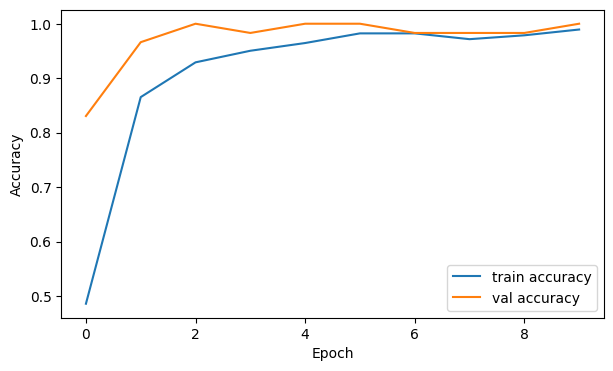

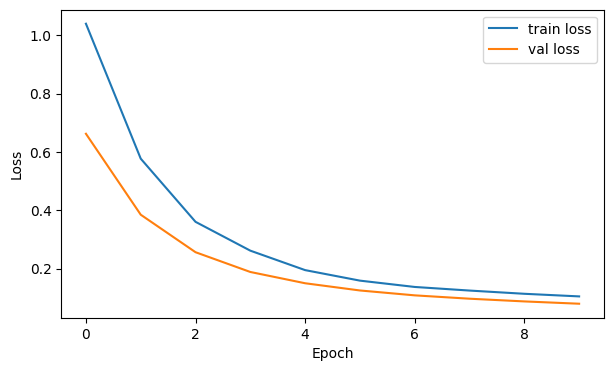

In [22]:
# Completa las cuatro curvas usando el objeto history
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Análisis corto de las curvas**

- **Accuracy:** la de train sube de 0.49 a casi 0.99 en pocas épocas, y la de validation arranca en 0.83 y se mantiene entre 0.98 y 1.0. Ambas terminan altas y juntas.
- **Loss:** las dos bajan de forma suave y constante, sin subidas. La de validation queda por debajo de la de train todo el tiempo.
- **Overfitting:** no se ve. La `val_loss` nunca sube ni se separa de la de train, que es la señal que habría que buscar.
- **Validation por encima de train:** es normal aquí, porque train usa augmentation y dropout (examen más difícil) y validation no.
- **Todavía mejora:** la loss seguía bajando en la época 10, así que con más épocas podría mejorar un poco más.
- **Precaución:** validation tiene pocas imágenes (unas 59), así que el 100 % puede ser optimista; la medida real es el test.

# PUNTO DE CONTROL — FIN DEL TRABAJO EN CLASE

Antes de continuar, verifica que tu equipo tenga:

- [ ] 3 clases definidas;
- [ ] términos de búsqueda documentados;
- [ ] imágenes descargadas;
- [ ] dataset inspeccionado y parcialmente limpiado;
- [ ] separación `train / validation / test`;
- [ ] EfficientNetB0 con pesos de ImageNet;
- [ ] backbone congelado;
- [ ] nueva cabeza de clasificación;
- [ ] al menos un entrenamiento completado;
- [ ] `accuracy` y `val_accuracy` reportadas.

## Hasta aquí llega el trabajo de clase.

**No uses todavía el conjunto de test para tomar decisiones.**

---

# PARTE B — TRABAJO EN CASA

A partir de este punto debes completar el análisis de manera autónoma.

Ahora sí vas a:

1. evaluar el modelo en `test`;
2. estudiar la matriz de confusión y métricas por clase;
3. realizar fine-tuning;
4. comparar el modelo congelado contra el modelo ajustado;
5. analizar errores;
6. escribir las conclusiones.

# 7. Evaluación del primer modelo — EN CASA

Ahora sí utilizaremos el conjunto de prueba.

> **Concepto clave — No todo es accuracy**
>
> - **Precision:** de las imágenes que el modelo predijo como una clase, ¿cuántas eran correctas?
> - **Recall:** de las imágenes que realmente pertenecían a una clase, ¿cuántas encontró?
> - **F1:** combina precision y recall.
> - **Matriz de confusión:** muestra qué clases se están confundiendo entre sí.

Guarda esta evaluación: será nuestra línea base antes del fine-tuning.

In [23]:
test_loss_before, test_acc_before = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy antes del fine-tuning: {test_acc_before:.4f}")

Test accuracy antes del fine-tuning: 0.9841


              precision    recall  f1-score   support

    guitarra      0.947     1.000     0.973        18
    trompeta      1.000     1.000     1.000        21
      violin      1.000     0.958     0.979        24

    accuracy                          0.984        63
   macro avg      0.982     0.986     0.984        63
weighted avg      0.985     0.984     0.984        63



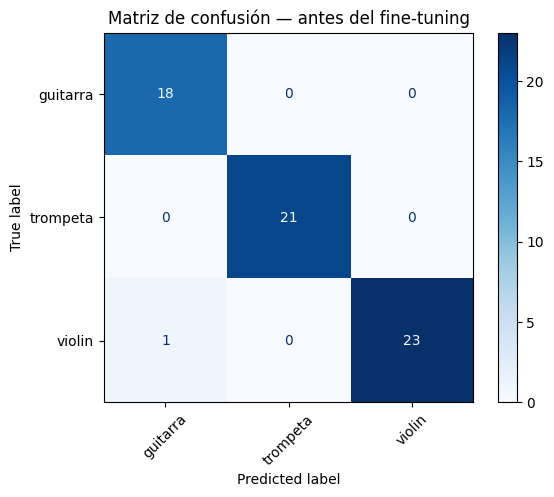

In [24]:
def get_predictions(model, dataset):
    y_true = np.concatenate([y.numpy() for _, y in dataset])
    probabilities = model.predict(dataset, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    return y_true, y_pred, probabilities

y_true, y_pred, probabilities = get_predictions(model, test_ds)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — antes del fine-tuning")
plt.show()

In [25]:
baseline = {
    "test_accuracy": 0.9841,
    "errores": 1,
    "total_test": 63,
}
baseline

{'test_accuracy': 0.9841, 'errores': 1, 'total_test': 63}

## TODO 4 — EN CASA: interpreta la evaluación

Utilizando `classification_report` y la matriz de confusión, responde:

**1. ¿Cuál clase obtuvo mejores resultados?**
La trompeta, porque acertó las 21 imágenes y ninguna otra clase se confundió con ella (precision y recall de 1.0).

**2. ¿Cuál fue la principal confusión?**
Un violín que el modelo predijo como guitarra, que es el único error de toda la matriz (1 de 63).

**3. ¿La accuracy global oculta algún problema por clase?**
Sí, un poco: el 98.4 % se ve casi perfecto, pero por clase se nota que el único error cayó en el violín (recall 0.958) y que la guitarra "absorbió" ese error (precision 0.947), además de que con solo 18 a 24 imágenes por clase un error pesa mucho.

**4. ¿Qué cambiarías primero en el dataset antes de cambiar el modelo?**
Revisaría y limpiaría a mano las fotos incorrectas (diagramas, guitarras eléctricas, violonchelos) y agregaría más fotos de violín y guitarra con fondos y ángulos variados, para que el modelo no dependa del fondo y para tener un test más grande y confiable.

# 8. Fine-tuning — EN CASA

Ahora permitiremos que una pequeña parte de EfficientNet se adapte al nuevo problema.

> **Concepto clave — Fine-tuning**
>
> En la fase anterior, los pesos del backbone no cambiaron. Ahora descongelaremos únicamente una parte final del modelo y la actualizaremos con un **learning rate mucho menor**.

> **Concepto clave — Batch Normalization**
>
> EfficientNet contiene capas `BatchNormalization`, que mantienen estadísticas internas aprendidas durante el entrenamiento. En datasets pequeños conviene mantenerlas congeladas durante fine-tuning para evitar actualizaciones inestables de esas estadísticas.

Después de cambiar qué capas son entrenables, es necesario **recompilar** el modelo.

In [26]:
base_model.trainable = True

# TODO 5 — Decide cuántas capas finales adaptar.
# Empieza con ~20. Puedes justificar otro valor usando validation.
N_UNFROZEN = 20

for layer in base_model.layers[:-N_UNFROZEN]:
    layer.trainable = False

# Mantener Batch Normalization congelado.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Capas entrenables de la base:",
    sum(layer.trainable for layer in base_model.layers),
    "/",
    len(base_model.layers),
)

Capas entrenables de la base: 15 / 238


## TODO 5 — EN CASA: realiza fine-tuning

Recompila y continúa el entrenamiento.

Usa como punto de partida:

- `Adam(learning_rate=1e-5)`;
- `SparseCategoricalCrossentropy`;
- `accuracy`;
- entre **3 y 8 épocas** adicionales;
- `EarlyStopping` sobre `val_loss`.

Tu decisión principal aquí es **cuántas capas descongelar**. Justifícala usando el desempeño de validación, no el conjunto de prueba.

In [27]:
# TODO 5 — EN CASA: completa el fine-tuning

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 1e-5
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,  # entre 3 y 8
    callbacks=[early_stopping_ft],
)

Epoch 1/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.9894 - loss: 0.0918 - val_accuracy: 1.0000 - val_loss: 0.0733
Epoch 2/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.9894 - loss: 0.0839 - val_accuracy: 1.0000 - val_loss: 0.0684
Epoch 3/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.9858 - loss: 0.0812 - val_accuracy: 1.0000 - val_loss: 0.0641
Epoch 4/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.9894 - loss: 0.0788 - val_accuracy: 1.0000 - val_loss: 0.0601
Epoch 5/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.9965 - loss: 0.0703 - val_accuracy: 1.0000 - val_loss: 0.0572
Epoch 6/6
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.9823 - loss: 0.0706 - val_accuracy: 0.9831 - val_loss: 0.0546


Descongelé las últimas 20 capas de EfficientNetB0 (con BatchNormalization congelado) y usé un learning rate de 1e-5. En validation, la val_loss bajó de 0.0798 (fase 1) a 0.0546 tras 6 épocas de fine-tuning, y la val_accuracy se mantuvo entre 0.98 y 1.0. No vi señales de overfitting, porque la val_loss bajó de forma constante. Como validation es muy pequeño y ya estaba en el techo, no puedo distinguir con confianza si 20 capas es mejor que otro valor; elegí 20 por ser el punto de partida recomendado, que adapta solo las características más específicas.

# 9. Comparación final — EN CASA

Compara el desempeño del mismo sistema **antes y después** del fine-tuning.

Una mejora pequeña también puede ser válida. Si el resultado empeora, no significa que el experimento “salió mal”: debes interpretar por qué pudo ocurrir.

In [28]:
test_loss_after, test_acc_after = model.evaluate(test_ds, verbose=0)
print(f"Antes del fine-tuning  : {test_acc_before:.4f}")
print(f"Después del fine-tuning: {test_acc_after:.4f}")
print(f"Diferencia              : {test_acc_after-test_acc_before:+.4f}")

Antes del fine-tuning  : 0.9841
Después del fine-tuning: 0.9841
Diferencia              : +0.0000


              precision    recall  f1-score   support

    guitarra      0.947     1.000     0.973        18
    trompeta      1.000     1.000     1.000        21
      violin      1.000     0.958     0.979        24

    accuracy                          0.984        63
   macro avg      0.982     0.986     0.984        63
weighted avg      0.985     0.984     0.984        63



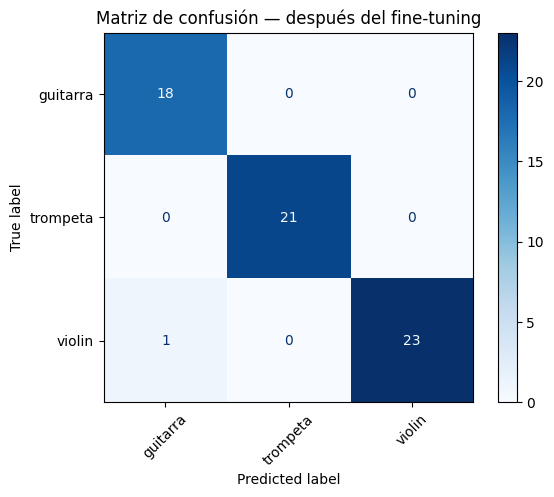

In [29]:
y_true_ft, y_pred_ft, probabilities_ft = get_predictions(model, test_ds)
print(classification_report(y_true_ft, y_pred_ft, target_names=class_names, digits=3))
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — después del fine-tuning")
plt.show()

# 10. Analiza los errores — EN CASA

Una métrica no explica por qué falla un modelo. Debes inspeccionar ejemplos clasificados incorrectamente.

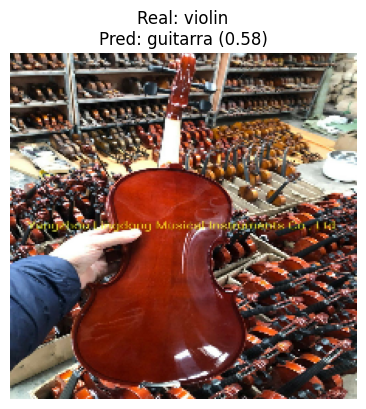

In [30]:
def show_mistakes(dataset, model, class_names, max_images=12):
    mistakes = []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = probs.argmax(axis=1)
        for image, true_label, pred_label, prob in zip(images.numpy(), labels.numpy(), preds, probs):
            if true_label != pred_label:
                mistakes.append((image.astype("uint8"), int(true_label), int(pred_label), float(prob[pred_label])))
    random.shuffle(mistakes)
    mistakes = mistakes[:max_images]
    if not mistakes:
        print("No se encontraron errores en este conjunto.")
        return
    cols = 4
    rows = int(np.ceil(len(mistakes)/cols))
    plt.figure(figsize=(16, 4*rows))
    for i, (image, true_label, pred_label, confidence) in enumerate(mistakes):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(image)
        ax.set_title(f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})")
        ax.axis("off")
    plt.tight_layout()

show_mistakes(test_ds, model, class_names)

## TODO 6 — EN CASA: análisis de errores y conclusiones

Selecciona al menos **5 errores** del modelo y analiza su causa probable.

El modelo solo cometió un error en las 63 imágenes de test (accuracy de 0.9841, igual antes y después del fine-tuning), por lo que no hay cinco errores reales que analizar

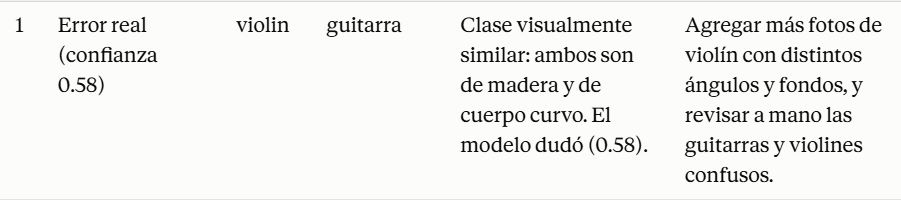

Posibles causas: imagen ambigua, etiqueta incorrecta y fondo engañoso.

Después, escribe una conclusión breve respondiendo:

Qué aprendiste al construir el dataset?
Que los datos de un buscador no son confiables tal cual y que revisarlos y limpiarlos pesa tanto como entrenar el modelo.

¿Cuál fue el principal problema de calidad?
Los duplicados y casi duplicados: en mi primera descarga eliminé 230 de unas 695 imágenes (más de la tercera parte), que habrían causado data leakage entre train y test.

¿Cuánto cambió el desempeño después del fine-tuning?
En test no cambió (0.9841 antes y después, +0.0000, el mismo error de 63), pero en validation la val_loss bajó de 0.0798 a 0.0546.

¿El fine-tuning ayudó? ¿Por qué?
Ayudó muy poco: mejoró la pérdida en validation, pero no se ve en test porque el modelo ya estaba casi perfecto con la base congelada y el test es tan pequeño que un solo error decide el resultado.

¿Qué mejorarías primero: datos, entrenamiento o arquitectura?
Los datos, porque el único error parece venir de ejemplos ambiguos y de un test pequeño; más fotos variadas y una limpieza manual aportarían más que cambiar la arquitectura.

# 🏠 Cierre conceptual — ENTREGA

Como parte del **TODO 6**, explica con tus propias palabras la diferencia entre:

Feature extraction / transfer learning con base congelada: es como contratar a alguien que ya sabe reconocer objetos y solo enseñarle los nombres de mis tres categorías. La red preentrenada se queda tal cual y yo solo entreno la parte final que clasifica.

Fine-tuning: es el siguiente paso: además de la parte final, dejo que las últimas capas de la red preentrenada se “afinen” con mis fotos. Se hace con cambios muy pequeños (learning rate bajo) para no borrar lo que ya sabía.

Entrenar una CNN desde cero: es como enseñarle a ver a alguien que nunca ha visto nada. La red parte sin ningún conocimiento y debe aprender todo solo con mis imágenes, por eso necesita muchas más fotos, más tiempo y más poder de cómputo, y con pocos datos tiende a memorizar.

No describas solo el código. Explica **qué parámetros se están aprendiendo y de dónde viene el conocimiento inicial**.

# ✅ Checklist de entrega

Antes de entregar verifica:

### Evidencia del trabajo en clase
- [ ] Problema y clases definidos.
- [ ] Dataset construido y revisado.
- [ ] Train / validation / test creados.
- [ ] Primer modelo con backbone congelado entrenado.

### Trabajo en casa
- [ ] Evaluación sobre test.
- [ ] Matriz de confusión.
- [ ] Precision / recall / F1 interpretados.
- [ ] Fine-tuning ejecutado.
- [ ] Comparación antes vs. después del fine-tuning.
- [ ] Al menos 5 errores analizados.
- [ ] Conclusión final escrita.

### Opcional
- [ ] Imagen externa.
- [ ] Experimento adicional / reto.

# Rúbrica sugerida

| Componente | Peso |
|---|---:|
| TODO 1 — Problema y estrategia de búsqueda | 10% |
| TODO 2 — Construcción, inspección y limpieza del dataset | 20% |
| Split y pipeline de datos | 10% |
| TODO 3 — Transfer learning + curvas | 20% |
| TODO 4 — Evaluación e interpretación | 10% |
| TODO 5 — Fine-tuning y comparación | 15% |
| TODO 6 — Análisis de errores + conclusión conceptual | 15% |
| **Total** | **100%** |